# Task 2: JADES Lya Templates

Using **JWST/NIRSpec prism** spectra from JADES DR4 — same instrument for both templates and evaluation, so no resolution mismatch.

## Intrinsic vs Attenuated

**Intrinsic**: what the galaxy truly emits. At z≤5.5 the IGM is nearly transparent → observed ≈ intrinsic.

**Attenuated**: observed spectrum after IGM absorption. At z~7.5 the IGM is ~50% neutral — GP trough wipes the blue side, damping wing suppresses the red wing near 1216 Å.

| Role | z range | Reason |
|------|---------|--------|
| Intrinsic templates (Task 3) | z=4–5.5 | Lya in NIRSpec range, IGM transparent |
| Evaluation data (Task 5) | z=7–8 | Reionization era — model applied here |

In [ ]:
from pathlib import Path
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits

JADES_DIR = Path('/home/aryana/Documents/GitHub/multimodal_superresolution/data/JADES/DR4')
LYA_REST  = 1216.0   # Å
UM_TO_AA  = 1e4      # microns → Å

cat  = Table.read(JADES_DIR / 'Combined_DR4_external_v1.2.1.fits')
z    = np.array(cat['z_Spec'],      dtype=float)
flag = np.array(cat['z_Spec_flag'], dtype=str)
nid  = np.array(cat['NIRSpec_ID'],  dtype=int)

# Build NIRSpec_ID → prism x1d path
all_prism  = glob.glob(str(JADES_DIR / '**' / '*prism*x1d*.fits'), recursive=True)
id_to_path = {int(Path(p).stem.split('_')[4].split('-')[-1]): p for p in all_prism}

print(f'Catalog objects         : {len(cat)}')
print(f'Prism x1d files indexed : {len(id_to_path)}')
print(f'Templates z=4-5.5 (A/B) : {((z>=4)&(z<=5.5)&np.isin(flag,["A","B"])).sum()}')
print(f'Evaluation z=7-8        : {((z>=7)&(z<8)).sum()}')

Catalog objects         : 5190
Prism x1d files indexed : 5929
Templates z=4-5.5 (A/B) : 422
Evaluation z=7-8        : 110


In [ ]:
def load_spectrum(obj_id):
    path = id_to_path.get(obj_id)
    if not path:
        return None, None
    with fits.open(path) as h:
        data = h['EXTRACT5PIX1D'].data
        wav  = np.array(data['WAVELENGTH'], dtype=float) * UM_TO_AA  # obs Å
        flux = np.array(data['FLUX'],       dtype=float)
        err  = np.array(data['FLUX_ERR'],   dtype=float)
    flux[(err <= 0) | ~np.isfinite(flux)] = np.nan
    return wav, flux

def lya_window(wav_obs, flux, z_obj, half_width=60):
    wav_r = wav_obs / (1 + z_obj)
    m = np.abs(wav_r - LYA_REST) < half_width
    return wav_r[m], flux[m]

## 1. Intrinsic templates — z=4–5.5

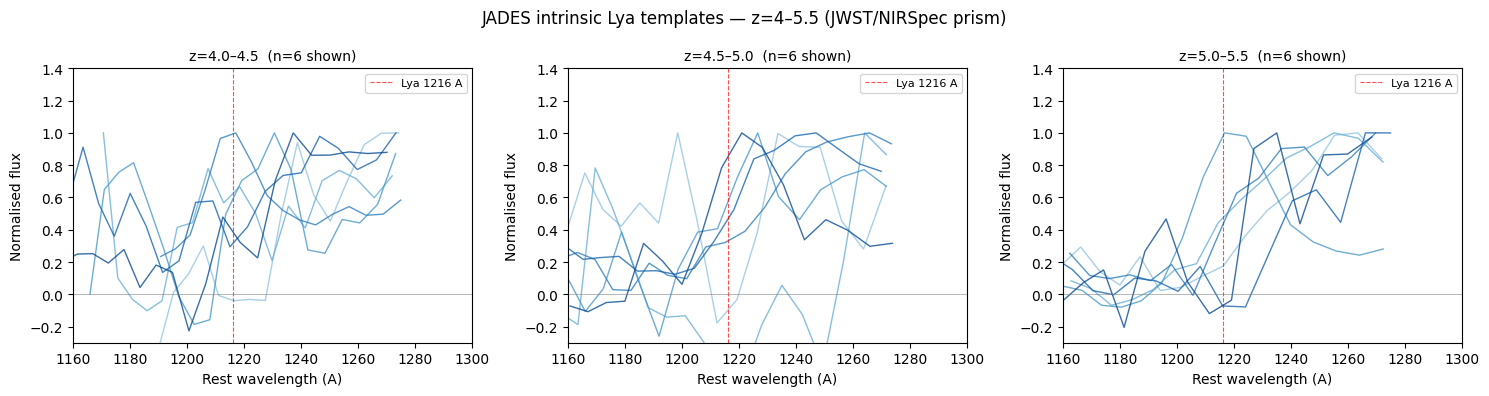

In [ ]:
z_bins = [(4.0, 4.5), (4.5, 5.0), (5.0, 5.5)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (zlo, zhi) in zip(axes, z_bins):
    sub    = cat[(z >= zlo) & (z < zhi) & np.isin(flag, ['A', 'B'])]
    colors = plt.cm.Blues(np.linspace(0.4, 0.9, 6))
    n = 0
    for row, col in zip(sub, colors):
        if n >= 6: break
        w, f = load_spectrum(int(row['NIRSpec_ID']))
        if w is None: continue
        wr, fr = lya_window(w, f, float(row['z_Spec']))
        if len(wr) < 5 or np.nanmax(fr) <= 0: continue
        ax.plot(wr, fr / np.nanmax(fr), color=col, lw=1.0, alpha=0.8)
        n += 1
    ax.axvline(LYA_REST, color='red', lw=0.8, ls='--', alpha=0.7, label='Lya 1216 A')
    ax.axhline(0, color='gray', lw=0.4)
    ax.set_xlim(1160, 1300); ax.set_ylim(-0.3, 1.4)
    ax.set_title(f'z={zlo}–{zhi}  (n={n} shown)', fontsize=10)
    ax.set_xlabel('Rest wavelength (A)'); ax.set_ylabel('Normalised flux')
    ax.legend(fontsize=8)

fig.suptitle('JADES intrinsic Lya templates — z=4–5.5 (JWST/NIRSpec prism)', fontsize=12)
fig.tight_layout()
plt.show()

## 2. Evaluation data — z=7–8 (attenuated by reionization-era IGM)

Evaluation objects at z=7-8: 110


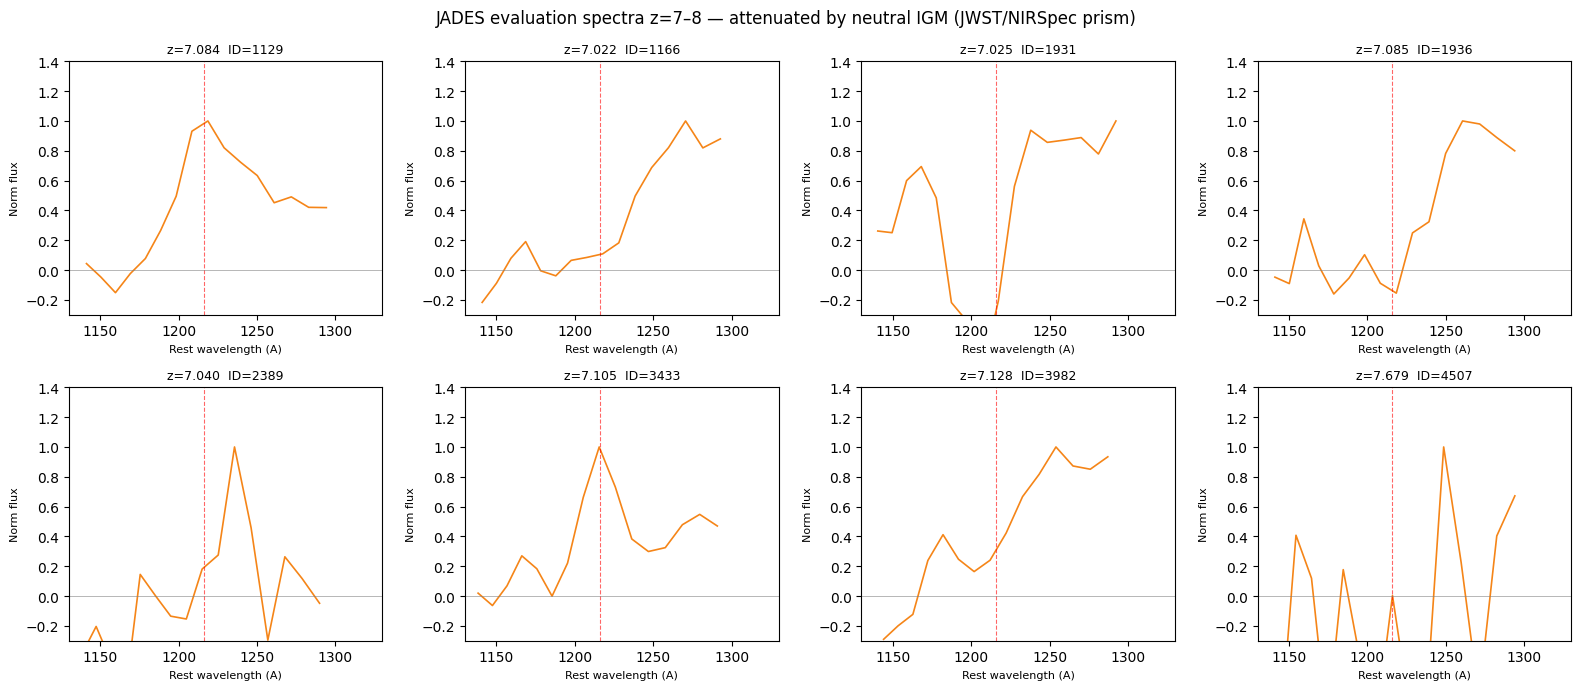

In [ ]:
eval_objs = cat[(z >= 7.0) & (z < 8.0)]
print(f'Evaluation objects at z=7-8: {len(eval_objs)}')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
n = 0
for row in eval_objs:
    if n >= 8: break
    w, f = load_spectrum(int(row['NIRSpec_ID']))
    if w is None: continue
    z_obj = float(row['z_Spec'])
    wr, fr = lya_window(w, f, z_obj, half_width=80)
    if len(wr) < 5 or np.nanmax(fr) <= 0: continue
    axes[n].plot(wr, fr / np.nanmax(fr), color='#F58518', lw=1.2)
    axes[n].axvline(LYA_REST, color='red', lw=0.8, ls='--', alpha=0.6)
    axes[n].axhline(0, color='gray', lw=0.4)
    axes[n].set_xlim(1130, 1330); axes[n].set_ylim(-0.3, 1.4)
    axes[n].set_title(f'z={z_obj:.3f}  ID={int(row["NIRSpec_ID"])}', fontsize=9)
    axes[n].set_xlabel('Rest wavelength (A)', fontsize=8)
    axes[n].set_ylabel('Norm flux', fontsize=8)
    n += 1
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('JADES evaluation spectra z=7–8 — attenuated by neutral IGM (JWST/NIRSpec prism)', fontsize=12)
fig.tight_layout()
plt.show()

## 3. Intrinsic vs attenuated — same instrument, side by side

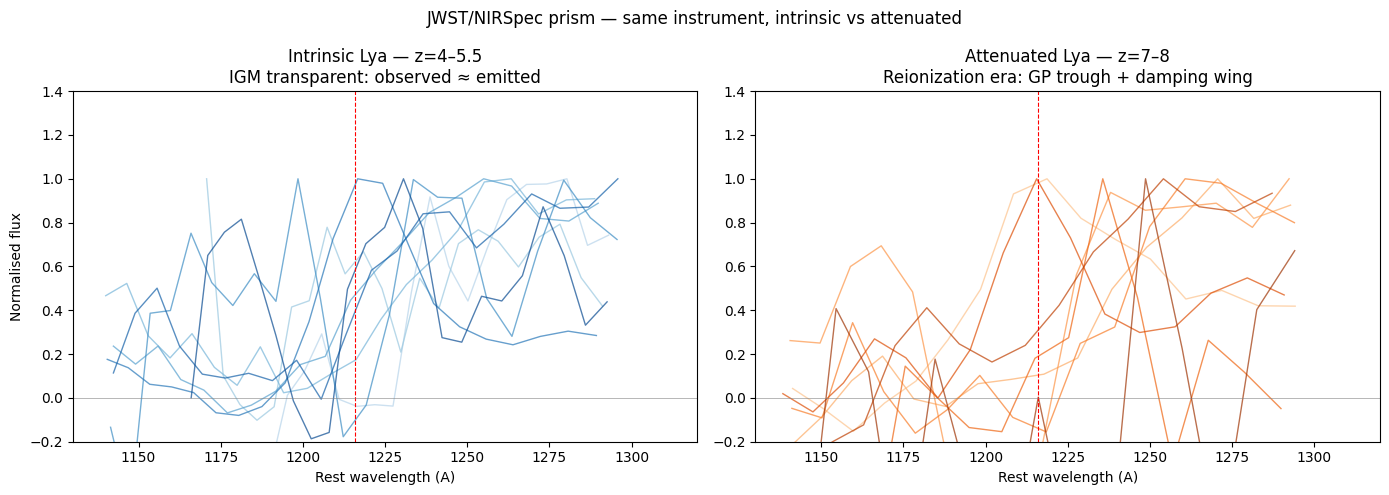

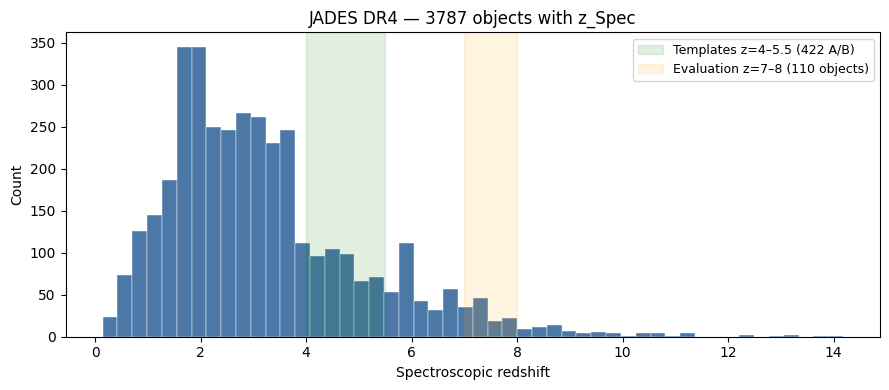

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — intrinsic (z=4-5.5)
ax = axes[0]
tmpl_mask = (z >= 4.0) & (z <= 5.5) & np.isin(flag, ['A', 'B'])
colors = plt.cm.Blues(np.linspace(0.3, 0.9, 8))
n = 0
for row, col in zip(cat[tmpl_mask], colors):
    if n >= 8: break
    w, f = load_spectrum(int(row['NIRSpec_ID']))
    if w is None: continue
    wr, fr = lya_window(w, f, float(row['z_Spec']), half_width=80)
    if len(wr) < 5 or np.nanmax(fr) <= 0: continue
    ax.plot(wr, fr / np.nanmax(fr), color=col, lw=1.0, alpha=0.7)
    n += 1
ax.axvline(LYA_REST, color='red', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.4)
ax.set_xlim(1130, 1320); ax.set_ylim(-0.2, 1.4)
ax.set_xlabel('Rest wavelength (A)'); ax.set_ylabel('Normalised flux')
ax.set_title('Intrinsic Lya — z=4–5.5\nIGM transparent: observed ≈ emitted')

# Right — attenuated (z=7-8)
ax = axes[1]
colors2 = plt.cm.Oranges(np.linspace(0.3, 0.9, 8))
n = 0
for row, col in zip(eval_objs, colors2):
    if n >= 8: break
    w, f = load_spectrum(int(row['NIRSpec_ID']))
    if w is None: continue
    wr, fr = lya_window(w, f, float(row['z_Spec']), half_width=80)
    if len(wr) < 5 or np.nanmax(fr) <= 0: continue
    ax.plot(wr, fr / np.nanmax(fr), color=col, lw=1.0, alpha=0.7)
    n += 1
ax.axvline(LYA_REST, color='red', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.4)
ax.set_xlim(1130, 1320); ax.set_ylim(-0.2, 1.4)
ax.set_xlabel('Rest wavelength (A)')
ax.set_title('Attenuated Lya — z=7–8\nReionization era: GP trough + damping wing')

fig.suptitle('JWST/NIRSpec prism — same instrument, intrinsic vs attenuated', fontsize=12)
fig.tight_layout()
plt.show()

# Redshift distribution
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(z[z > 0], bins=50, color='#4C78A8', edgecolor='white', lw=0.3)
ax.axvspan(4.0, 5.5, alpha=0.12, color='green',
           label=f'Templates z=4–5.5 ({((z>=4)&(z<=5.5)&np.isin(flag,["A","B"])).sum()} A/B)')
ax.axvspan(7.0, 8.0, alpha=0.12, color='orange',
           label=f'Evaluation z=7–8 ({((z>=7)&(z<8)).sum()} objects)')
ax.set_xlabel('Spectroscopic redshift'); ax.set_ylabel('Count')
ax.set_title(f'JADES DR4 — {(z>0).sum()} objects with z_Spec')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()